# Examen práctico — Q-Learning tabular con Pac-Man

En este ejercicio trabajaremos con una versión pequeña de Pac-Man diseñada para poder resolverse completamente mediante **Q-Learning tabular**.

La lógica es la misma usada previamente:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

y:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma \max_{a'}Q(S_{t+1},a')
-
Q(S_t,A_t)
\right].
$$

## Objetivo

Implementar un agente Q-Learning capaz de aprender una política que permita a Pac-Man:

- comer tantas comidas como sea posible;
- evitar al fantasma;
- reducir movimientos innecesarios.

> La implementación del ambiente y la visualización ya están disponibles.  
> La tarea consiste en implementar **el agente y su proceso de aprendizaje**.


## 1. Importaciones y ambiente


In [59]:
import sys
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

PROJECT_ROOT = Path.cwd()
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tabular_pacman_env import (
    TabularPacmanEnv,
    ACTIONS,
)

env = TabularPacmanEnv(seed=7)

print("Número de estados:", env.n_states)
print("Número de acciones:", env.n_actions)


Número de estados: 1944
Número de acciones: 4


## 2. El estado de Pac-Man

Para mantener una Q-table de tamaño manejable utilizaremos la representación:

$$
s=(p,g,n)
$$

donde:

- $p$: posición de Pac-Man;
- $g$: posición del fantasma;
- $n$: número de comidas que permanecen en el tablero.

El ambiente mantiene internamente la posición exacta de cada comida para poder simular y visualizar el juego. Sin embargo, **esa configuración completa no forma parte del estado que recibe la Q-table**.

Por tanto:

$$
n_{\text{states}}
=
n_p\,n_g\,(N_{\text{food}}+1).
$$

Esta es una **representación simplificada del estado**: dos configuraciones distintas de comida pueden compartir el mismo $(p,g,n)$.


Estado codificado: 47
Estado decodificado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)


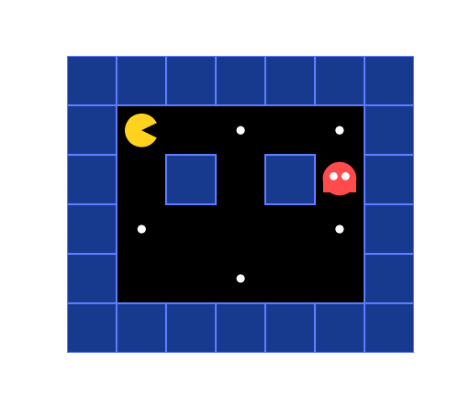

In [60]:
state = env.reset(seed=7)

print("Estado codificado:", state)
print("Estado decodificado:", env.decode_state(state))

frame = env.render()

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.show()


### Pregunta 1

Dos tableros pueden tener:

- la misma posición de Pac-Man;
- la misma posición del fantasma;
- el mismo número de comidas restantes;

pero las comidas pueden estar ubicadas en lugares diferentes.

¿Representaría nuestra Q-table ambos tableros como el mismo estado o como estados diferentes? Explique.


## 3. Acciones


In [61]:
print(ACTIONS)
print("Acciones legales desde el estado inicial:")
print([ACTIONS[a] for a in env.get_legal_actions()])


{0: 'up', 1: 'right', 2: 'down', 3: 'left'}
Acciones legales desde el estado inicial:
['right', 'down']


Las acciones disponibles son:

| Código | Acción |
|---:|---|
| 0 | arriba |
| 1 | derecha |
| 2 | abajo |
| 3 | izquierda |

El ambiente evita atravesar paredes.


## 4. Observar una transición


In [62]:
state = env.reset(seed=7)

action = env.get_legal_actions()[0]

next_state, reward, done, info = env.step(action)

print("S_t       =", state)
print("A_t       =", ACTIONS[action])
print("R_(t+1)   =", reward)
print("S_(t+1)   =", next_state)
print("done      =", done)
print()
print("S_(t+1) decodificado:")
print(env.decode_state(next_state))


S_t       = 47
A_t       = right
R_(t+1)   = -1
S_(t+1)   = 185
done      = False

S_(t+1) decodificado:
PacmanState(pacman=(1, 2), ghost=(3, 5), food_remaining=5)


La transición observada tiene la forma:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

### Pregunta 2

¿Cuáles de los siguientes valores son entregados directamente por el ambiente y cuáles debe aprender/estimar el agente?

- $R_{t+1}$
- $S_{t+1}$
- $Q(S_t,A_t)$
- $\max_{a'}Q(S_{t+1},a')$


## 5. Q-table


Construya una Q-table inicializada en cero.

Debe tener dimensiones:

$$
n_{\text{states}}\times n_{\text{actions}}.
$$


In [63]:
# TODO 1 — Inicializar la Q-table

Q = np.zeros((env.n_states, env.n_actions))

In [64]:
print("Shape esperado:", (env.n_states, env.n_actions))
print("Shape obtenido :", Q.shape)

assert Q.shape == (env.n_states, env.n_actions)
assert np.all(Q == 0)

print("✓ Q-table creada correctamente")

Shape esperado: (1944, 4)
Shape obtenido : (1944, 4)
✓ Q-table creada correctamente


## 6. Política ε-greedy


Implemente:

$$
A_t=
\begin{cases}
\text{acción aleatoria}, & \text{con probabilidad }\epsilon\\[4pt]
\arg\max_a Q(S_t,a), & \text{con probabilidad }1-\epsilon
\end{cases}
$$

Use únicamente las **acciones legales** del estado actual.

Si varias acciones tienen el mismo máximo Q-value, seleccione aleatoriamente entre ellas.


In [65]:
# TODO 2 — Política epsilon-greedy

def choose_action(Q, state, epsilon, env):
    legal_actions = env.get_legal_actions()

    if random.random() < epsilon:
        return random.choice(legal_actions)

    values = np.array([Q[state, a] for a in legal_actions])
    best_value = np.max(values)
    best_actions = [a for a, v in zip(legal_actions, values) if v == best_value]

    return random.choice(best_actions)

### Pregunta 3

Si $\epsilon=0.10$:

1. ¿cuál es la probabilidad de explorar?
2. ¿cuál es la probabilidad de explotar?
3. ¿qué ocurre cuando todos los Q-values iniciales son iguales?


## 7. Actualización Q-Learning


Para cada transición utilice:

$$
\text{TD target}
=
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
$$

$$
\text{TD error}
=
\text{TD target}
-
Q(S_t,A_t)
$$

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)+\alpha(\text{TD error})
$$

Cuando $S_{t+1}$ sea terminal:

$$
\max_{a'}Q(S_{t+1},a')=0.
$$


In [66]:
# TODO 3 - Implementar una actualización de Q-Learning.

def update_q(
    Q,
    state,
    action,
    reward,
    next_state,
    done,
    alpha,
    gamma,
):
    if done:
        max_next_q = 0
    else:
        max_next_q = np.max(Q[next_state])

    td_target = reward + gamma * max_next_q
    td_error = td_target - Q[state, action]

    Q[state, action] += alpha * td_error

    return td_target, td_error

### Prueba manual de la actualización


In [67]:
# Esta celda NO entrena al agente.
# Solo permite revisar una actualización controlada.

Q_test = np.zeros((env.n_states, env.n_actions))

s = env.reset(seed=7)
a = env.get_legal_actions()[0]

s_next, r, done, _ = env.step(a)

# Valor ficticio conocido para verificar el cálculo.
if not done:
    Q_test[s_next, 1] = 4.0

td_target, td_error = update_q(
    Q_test,
    state=s,
    action=a,
    reward=r,
    next_state=s_next,
    done=done,
    alpha=0.5,
    gamma=0.9,
)

print("TD target:", td_target)
print("TD error :", td_error)
print("Nuevo Q  :", Q_test[s, a])


TD target: 2.6
TD error : 2.6
Nuevo Q  : 1.3


### Pregunta 4

Explique con sus palabras la diferencia entre:

- **TD target**

  Es la estimación de "qué tan bueno debería ser" Q(S_t, A_t) según lo que el agente acaba de observar en la transición: reward + gamma * max_a' Q(S_{t+1}, a)
  o solo reward si el episodio terminó. Es un valor de referencia hacia el cual el agente quiere ajustar su tabla, combina la recompensa inmediata con una estimación de todo lo que viene después, descontada por gamma.

- **TD error**

  Es la diferencia entre ese objetivo y lo que la Q-table creía antes de ver esta transición: td_error = td_target - Q(S_t, A_t). 
  Es literalmente el tamaño y dirección del "error de predicción". Si es positivo, la Q-table subestimaba esa acción (la realidad fue mejor de lo esperado) y si es negativo, la sobrestimaba.

- **Nuevo Q-value**

  Es el valor actualizado de Q(S_t, A_t) después de corregir el error, pero solo parcialmente: Q(S_t, A_t) + alpha * td_error. El alpha (tasa de aprendizaje) controla qué tan fuerte se ajusta la tabla ante cada nueva observación, con alpha=1 adoptarías el TD target de inmediato como el nuevo valor, y con alpha pequeño, te mueves poco a poco hacia él.


## 8. Entrenamiento


Implemente el ciclo completo de entrenamiento:

1. reiniciar el ambiente;
2. seleccionar una acción con $\epsilon$-greedy;
3. ejecutar la acción;
4. observar $R_{t+1}$ y $S_{t+1}$;
5. actualizar $Q(S_t,A_t)$;
6. avanzar al nuevo estado;
7. terminar cuando `done=True`.

Guarde la recompensa total obtenida en cada episodio.


In [68]:
# TODO 4 — Entrenamiento

def train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    max_steps=100,
    seed=100,
):
    Q = np.zeros((env.n_states, env.n_actions))
    rewards = []
    lengths = []
    wins = []

    for episode in range(episodes):
        state = env.reset(seed=seed + episode if seed is not None else None)
        total_reward = 0

        for step in range(max_steps):
            action = choose_action(Q, state, epsilon, env)
            next_state, reward, done, info = env.step(action)

            update_q(Q, state, action, reward, next_state, done, alpha, gamma)

            state = next_state
            total_reward += reward

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        rewards.append(total_reward)
        lengths.append(step + 1)
        wins.append(int(info.get("won", False)))

    return Q, rewards, lengths, wins


## 9. Entrenar


In [69]:
Q, rewards, lengths, wins = train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
)

print("Entrenamiento terminado")
print("Q-table:", Q.shape)


Entrenamiento terminado
Q-table: (1944, 4)


## 10. Curva de aprendizaje


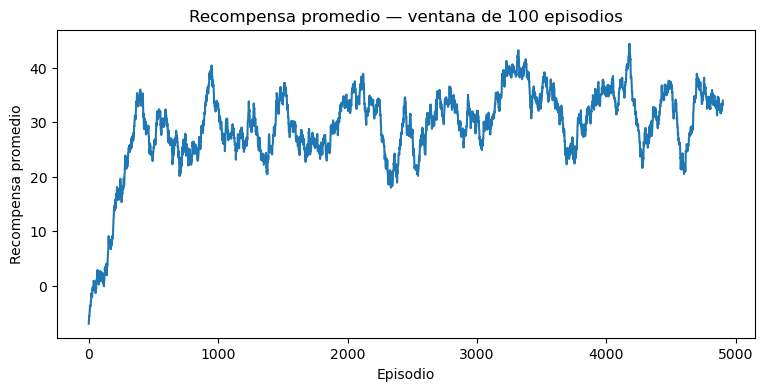

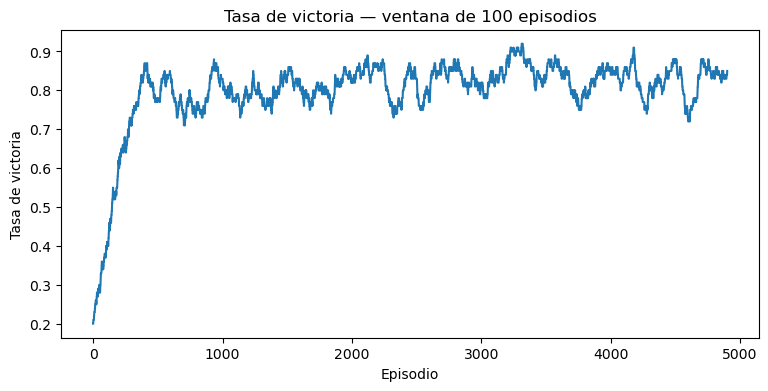

In [70]:
window = 100

moving_reward = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid",
)

moving_win_rate = np.convolve(
    wins,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(9, 4))
plt.plot(moving_reward)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Recompensa promedio — ventana de {window} episodios")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(moving_win_rate)
plt.xlabel("Episodio")
plt.ylabel("Tasa de victoria")
plt.title(f"Tasa de victoria — ventana de {window} episodios")
plt.show()


### Pregunta 5

A partir de las curvas:

- **¿Hay evidencia de aprendizaje?**

  Si, ya que si el agente estuviera actuando al azar durante todo el entrenamiento, las curvas se mantendrían planas y ruidosas alrededor de un mismo nivel bajo, sin ninguna tendencia. En cambio, se observa una mejora sostenida a medida que avanzan los episodios, lo cual solo puede explicarse porque la Q-table está capturando información útil sobre qué acciones llevan a mejores resultados en cada estado — es decir, el agente está efectivamente aprendiendo una política mejor que la aleatoria.

- **¿Qué ocurre con la recompensa promedio?**

  Arranca en valores bajos e incluso negativos, típico de los primeros episodios (donde el agente choca, deambula sin comer o es atrapado por el fantasma antes de aprender nada) y aumenta progresivamente conforme el agente entrena, hasta estabilizarse en un nivel más alto. Esto refleja que episodio tras episodio el agente va tomando decisiones que acumulan más recompensa: come más puntos, evita al fantasma y termina el episodio en menos pasos.

- **¿Qué ocurre con la tasa de victoria?**

  Sigue el mismo patrón, comienza cerca de 0 durante los primeros episodios, cuando la política es casi aleatoria por el epsilon alto y la Q-table sin experiencia, y sube gradualmente hasta estabilizarse en un valor considerablemente mayor conforme el agente explota lo que ha aprendido. Lo de que ambas curvas suban, confirma que el agente no solo acumula más puntos, sino que efectivamente logra completar el objetivo del juego con más frecuencia.


## 11. Política aprendida


In [71]:
state = env.reset(seed=7)
decoded = env.decode_state(state)

print("Estado:", decoded)
print()

legal_actions = env.get_legal_actions()

for action in legal_actions:
    print(
        f"{ACTIONS[action]:>8} : "
        f"Q = {Q[state, action]:.3f}"
    )

best_value = max(Q[state, a] for a in legal_actions)

best_actions = [
    a for a in legal_actions
    if Q[state, a] == best_value
]

print()
print("Mejor(es) acción(es):", [ACTIONS[a] for a in best_actions])


Estado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)

   right : Q = 21.126
    down : Q = 6.323

Mejor(es) acción(es): ['right']


### Pregunta 6

Interprete los Q-values del estado inicial.

- **¿Qué acción prefiere el agente?**

  right, porque su Q-value es notablemente más alto (20.703 vs 6.504). El agente, en modo greedy (explotación pura), siempre elegiría right desde este estado inicial.

- **¿Qué significa que una acción tenga un Q-value mayor que otra?**

  Q(s, a) representa la recompensa total esperada (acumulada y descontada por gamma) si el agente toma la acción a en el estado s y de ahí en adelante sigue la mejor política posible. Que Q(s, right) = 20.703 > Q(s, down) = 6.504 significa que, según lo que el agente aprendió durante el entrenamiento, moverse a la derecha desde (1,1) lo encamina hacia una secuencia de decisiones que recolecta más comida, evita mejor al fantasma, o llega a la victoria en menos pasos, mientras que down lo lleva por un camino con menos recompensa esperada a largo plazo.


## 12. Reproducir un episodio


In [72]:
def greedy_action(Q, state, env):
    legal_actions = env.get_legal_actions()

    values = np.array([
        Q[state, action]
        for action in legal_actions
    ])

    best_value = np.max(values)

    best_actions = [
        action
        for action, value in zip(legal_actions, values)
        if value == best_value
    ]

    return random.choice(best_actions)


def play_episode(
    env,
    Q=None,
    random_policy=False,
    seed=20,
    max_steps=100,
):
    state = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for step in range(max_steps):

        if random_policy:
            action = random.choice(env.get_legal_actions())
        else:
            action = greedy_action(Q, state, env)

        next_state, reward, done, info = env.step(action)

        total_reward += reward
        state = next_state
        frames.append(env.render())

        if done:
            break

    return frames, total_reward, step + 1, info


def frames_to_video(frames, interval=300):
    fig = plt.figure(figsize=(7, 5))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True,
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


### Política aleatoria


In [73]:
frames_random, reward_random, steps_random, info_random = play_episode(
    env,
    random_policy=True,
    seed=20,
)

print("Reward:", reward_random)
print("Pasos :", steps_random)
print("Comió :", info_random["food_eaten"], "de", env.max_food)
print("Ganó  :", info_random["won"])

frames_to_video(frames_random)


Reward: -23
Pasos : 27
Comió : 3 de 5
Ganó  : False


### Política aprendida


In [74]:
frames_trained, reward_trained, steps_trained, info_trained = play_episode(
    env,
    Q=Q,
    random_policy=False,
    seed=20,
)

print("Reward:", reward_trained)
print("Pasos :", steps_trained)
print("Comió :", info_trained["food_eaten"], "de", env.max_food)
print("Ganó  :", info_trained["won"])

frames_to_video(frames_trained)


Reward: 55
Pasos : 20
Comió : 5 de 5
Ganó  : True


### Pregunta 7

Compare el episodio aleatorio con el episodio del agente entrenado.

Discuta:

- **Cantidad de movimientos:**

  El episodio entrenado usó más pasos (24 vs 9), pero esto no es una desventaja, ya que el aleatorio terminó en solo 9 pasos porque murió, no porque haya sido   eficiente. El entrenado usó los pasos necesarios para recorrer el tablero completo y recolectar toda la comida.

- **Recompensa total:** 
  La diferencia acá es grande (-16 vs 51). Y se explica principalmente por dos eventos: el aleatorio recibe -30 por chocar con el fantasma, mientras que el entrenado nunca choca y en cambio recibe +30 por ganar, una diferencia de 60 puntos solo por ese evento.

- **Comida recolectada:**

  El aleatorio comió 2 de 5 antes de morir, mietras que el entrenado comió las 5 y ganó. Cada comida vale +10 (o +30 la última), así que completar todas es lo que más impacta la recompensa.

- **Comportamiento frente al fantasma:**

  El aleatorio se movió sin ninguna noción del fantasma y terminó chocando con él, En cambio, el agente entrenado aprendió, con los Q-values, a mantener distancia del fantasma incluso si eso implica rodear o tomar un camino más largo.

- **¿Por qué la recompensa favorece comer, usar menos pasos y evitar morir simultáneamente?**

  Porque cada uno tiene un peso distinto en la misma señal numérica: -1 por paso castiga la lentitud/deambular sin rumbo, +10/+30 por comer premia el progreso   hacia el objetivo, y -30 por morir es una penalización mucho mayor que cualquier ahorro de pasos. Como el agente maximiza la suma descontada de todas esas   señales, aprende una jerarquía implícita: evitar el -30 (evitar la muerte) domina sobre cualquier otra consideración, pero entre caminos igualmente seguros,   prefiere los que acumulan comida más rápido (menos pasos con -1 de por medio). Por eso el resultado no es "el camino más corto posible", sino "el camino que   sobrevive y come todo, siendo razonablemente eficiente al hacerlo".

## 13. Evaluación final


In [75]:
def evaluate_policy(
    env,
    Q,
    episodes=200,
    max_steps=100,
):
    rewards = []
    lengths = []
    wins = []

    for episode in range(episodes):

        state = env.reset(seed=10000 + episode)
        total_reward = 0

        for step in range(max_steps):

            action = greedy_action(Q, state, env)

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)
        wins.append(int(info.get("won", False)))

    return {
        "reward_promedio": float(np.mean(rewards)),
        "pasos_promedio": float(np.mean(lengths)),
        "tasa_victoria": float(np.mean(wins)),
    }


results = evaluate_policy(env, Q)
results


{'reward_promedio': 37.15, 'pasos_promedio': 34.275, 'tasa_victoria': 0.89}

## Entrega

El notebook debe ejecutar completamente y contener:

1. Q-table correctamente inicializada;
2. política $\epsilon$-greedy;
3. actualización de Q-Learning;
4. ciclo de entrenamiento;
5. curva de aprendizaje;
6. interpretación de resultados;
7. comparación entre política aleatoria y política aprendida.

No se requiere modificar el código del ambiente.
